In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

INPUT_FILE = r"C:\Users\mldar\OneDrive\Desktop\Infosys\raw\enhanced_on_time_delivery_dataset.xlsx"
df = pd.read_excel(INPUT_FILE)

print("Shape:", df.shape)
df.head()


Shape: (10999, 23)


,Mode_of_Shipment,Customer_rating,Cost_of_the_Product,Product_importance,Weight_in_gms,Reached.on.Time_Y.N,order_id,supplier_id,supplier_rating,supplier_lead_time,...,shipping_distance_km,unit_price,total_order_value,weather_condition,region,holiday_period,previous_on_time_rate,carrier_name,delayed_reason_code,on_time_delivery
0,Flight,2,177,low,1233,1,ORD00001,SUP_010,2.98,9,...,867,49.01,531,Storm,North,Yes,0.88,DHL,Customs,0
1,Flight,5,216,low,3088,1,ORD00002,SUP_016,3.29,6,...,882,42.08,432,Storm,East,No,0.60,FedEx,NaN,0
2,Flight,2,183,low,3374,1,ORD00003,SUP_017,2.74,13,...,1918,34.76,732,Storm,North,Yes,0.59,LocalTruckers,NaN,1
3,Flight,3,176,medium,1177,1,ORD00004,SUP_014,2.86,10,...,1393,32.70,704,Rainy,West,No,0.68,FedEx,Traffic,0
4,Flight,2,184,medium,2484,1,ORD00005,SUP_020,4.71,7,...,72,29.59,552,Storm,East,Yes,0.53,FedEx,NaN,1


In [2]:
# Fill numerical missing values with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [3]:
label_encoders = {}
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Categorical columns encoded successfully!")


Categorical columns encoded successfully!


In [4]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c != "Reached.on.Time_Y.N"]  # Exclude target variable

df[num_cols] = scaler.fit_transform(df[num_cols])

print("Numerical features scaled!")


Numerical features scaled!


In [5]:
if "Cost_of_the_Product" in df.columns and "Weight_in_gms" in df.columns:
    df["cost_weight_ratio"] = (
        df["Cost_of_the_Product"] / (df["Weight_in_gms"] + 1e-6)
    )


In [6]:
if "shipping_distance_km" in df.columns and "Customer_rating" in df.columns:
    df["distance_rating_ratio"] = (
        df["shipping_distance_km"] / (df["Customer_rating"] + 1e-6)
    )


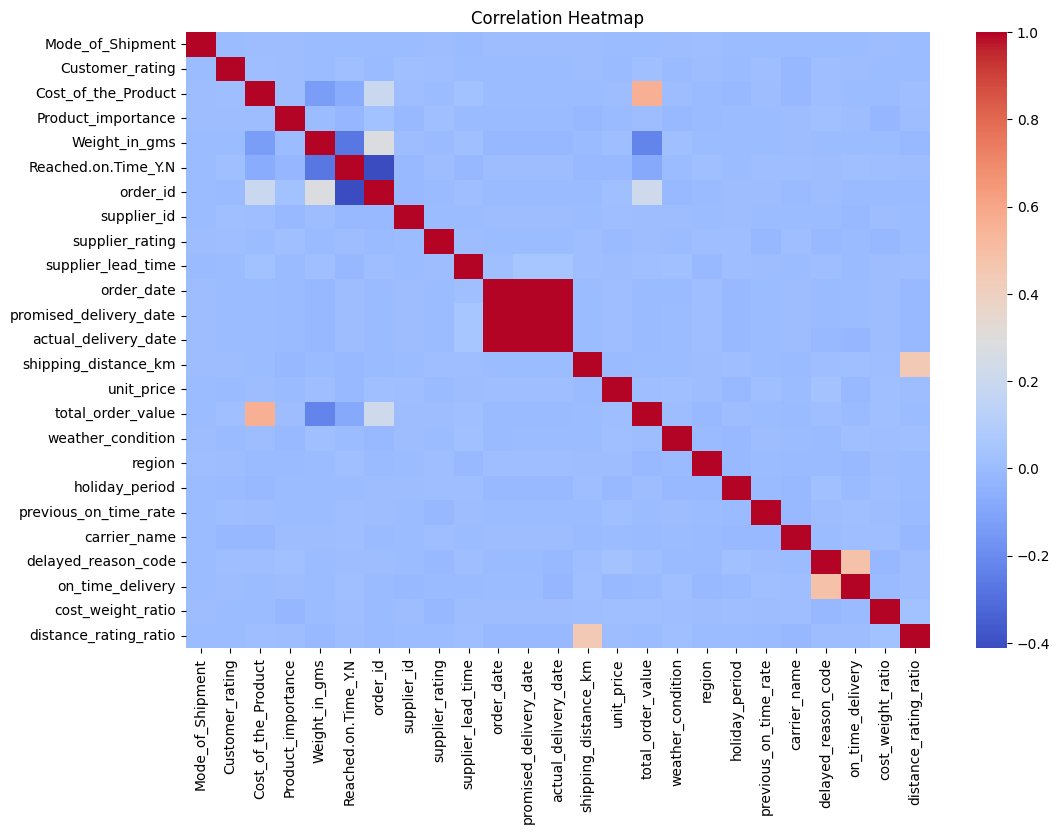

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [8]:
X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (8799, 24)
Test shape: (2200, 24)


In [10]:
import os
import pickle

# Create folder to store train-test splits
output_dir = r"C:\Users\mldar\OneDrive\Desktop\Infosys\processed"
os.makedirs(output_dir, exist_ok=True)

# Save train-test split data
with open(f"{output_dir}/X_train.pkl", "wb") as f:
    pickle.dump(X_train, f)

with open(f"{output_dir}/y_train.pkl", "wb") as f:
    pickle.dump(y_train, f)

with open(f"{output_dir}/X_test.pkl", "wb") as f:
    pickle.dump(X_test, f)

with open(f"{output_dir}/y_test.pkl", "wb") as f:
    pickle.dump(y_test, f)

print("All train-test files saved successfully!")


All train-test files saved successfully!


In [11]:
processed_file = r"C:\Users\mldar\OneDrive\Desktop\Infosys\processed\processed_dataset.xlsx"
df.to_excel(processed_file, index=False)

print("Processed dataset saved to:", processed_file)


Processed dataset saved to: C:\Users\mldar\OneDrive\Desktop\Infosys\processed\processed_dataset.xlsx
